In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv("farmer_loans_synthetic.csv")

In [26]:
plt.style.use("default")

In [40]:
df

,loan_id,farmer_id,region,land_holding_acres,prior_loan_count,prior_defaults,crop_type,season,loan_amount,interest_rate,loan_to_land_ratio,repayment_status,days_overdue
0,L100001,F20001,Baramati,2.7,0,0,Sugarcane,Rabi,42200,7.58,15630.0,Defaulted,155
1,L100002,F20002,Phaltan,2.0,2,0,Jowar,Kharif,24300,7.28,12150.0,Paid On Time,0
2,L100003,F20003,Phaltan,1.9,2,0,Cotton,Rabi,15000,9.44,7895.0,Paid On Time,0
3,L100004,F20004,Daund,1.6,2,0,Onion,Kharif,17000,11.02,10625.0,Paid On Time,0
4,L100005,F20005,Daund,5.4,4,0,Cotton,Kharif,64500,9.66,11944.0,Paid On Time,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,L103196,F23196,Baramati,4.7,0,0,Wheat,Kharif,42300,11.32,9000.0,Paid Late,27
3196,L103197,F23197,Indapur,4.0,0,0,Soybean,Kharif,32700,11.10,8175.0,Defaulted,183
3197,L103198,F23198,Malshiras,2.0,1,0,Jowar,Rabi,25100,8.09,12550.0,Defaulted,134
3198,L103199,F23199,Malshiras,3.8,3,0,Jowar,Rabi,36000,10.75,9474.0,Paid On Time,0


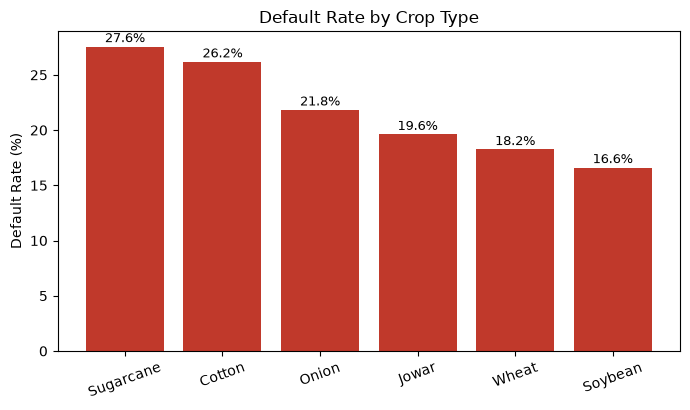

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.2))
rate_by_crop = (
    df.groupby("crop_type")["repayment_status"]
    .apply(lambda x: (x == "Defaulted").mean() * 100)
    .sort_values(ascending=False)
)
bars = ax.bar(rate_by_crop.index, rate_by_crop.values, color="#c0392b")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Crop Type")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4, f"{b.get_height():.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("charts/default_rate_by_crop.png", dpi=130)
plt.show()
plt.close()

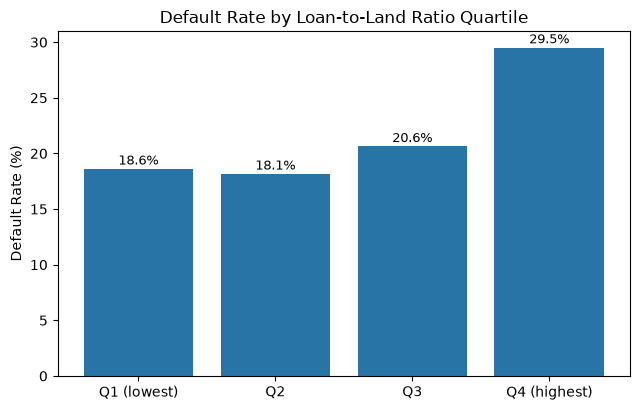

In [37]:
df["ratio_quartile"] = pd.qcut(df["loan_to_land_ratio"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
rate_by_q = df.groupby("ratio_quartile", observed=True)["repayment_status"].apply(lambda x: (x == "Defaulted").mean() * 100)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(rate_by_q.index.astype(str), rate_by_q.values, color="#2874a6")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Loan-to-Land Ratio Quartile")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4, f"{b.get_height():.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("charts/default_rate_by_ratio_quartile.png", dpi=130)
plt.show()
plt.close()

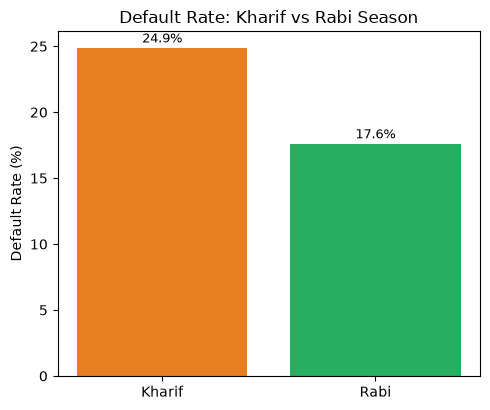

In [34]:
rate_by_season = df.groupby("season")["repayment_status"].apply(lambda x: (x == "Defaulted").mean() * 100)
fig, ax = plt.subplots(figsize=(5, 4.2))
bars = ax.bar(rate_by_season.index, rate_by_season.values, color=["#e67e22", "#27ae60"])
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate: Kharif vs Rabi Season")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4, f"{b.get_height():.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("charts/default_rate_by_season.png", dpi=130)
plt.show()
plt.close()

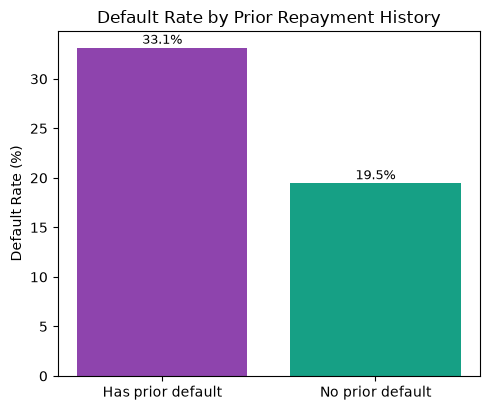

Charts saved to charts/
crop_type
Sugarcane    27.564103
Cotton       26.181818
Onion        21.828909
Jowar        19.611650
Wheat        18.245614
Soybean      16.611296
Name: repayment_status, dtype: float64


In [38]:
rate_by_hist = df.assign(
    history=lambda d: d["prior_defaults"].gt(0).map({True: "Has prior default", False: "No prior default"})
).groupby("history")["repayment_status"].apply(lambda x: (x == "Defaulted").mean() * 100)
fig, ax = plt.subplots(figsize=(5, 4.2))
bars = ax.bar(rate_by_hist.index, rate_by_hist.values, color=["#8e44ad", "#16a085"])
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Prior Repayment History")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.4, f"{b.get_height():.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("charts/default_rate_by_history.png", dpi=130)
plt.show()
plt.close()

print("Charts saved to charts/")
print(rate_by_crop)